# Imports

In [389]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings
from GP import *
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gpytorch
import gymnasium as gym
from gymnasium.envs.registration import register, registry, make, spec
import copy

from utils import make_env, Node, Tree, argm, value_iteration, data_keys
from MCTS import MonteCarloTreeSearch, simulate_agent
import IPython

import multiprocess as mp
import pingouin as pg
from scipy.special import expit

from agents import GPAgent, Farmer
from samplers import GridSampler


warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2AFC

## Simulations

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

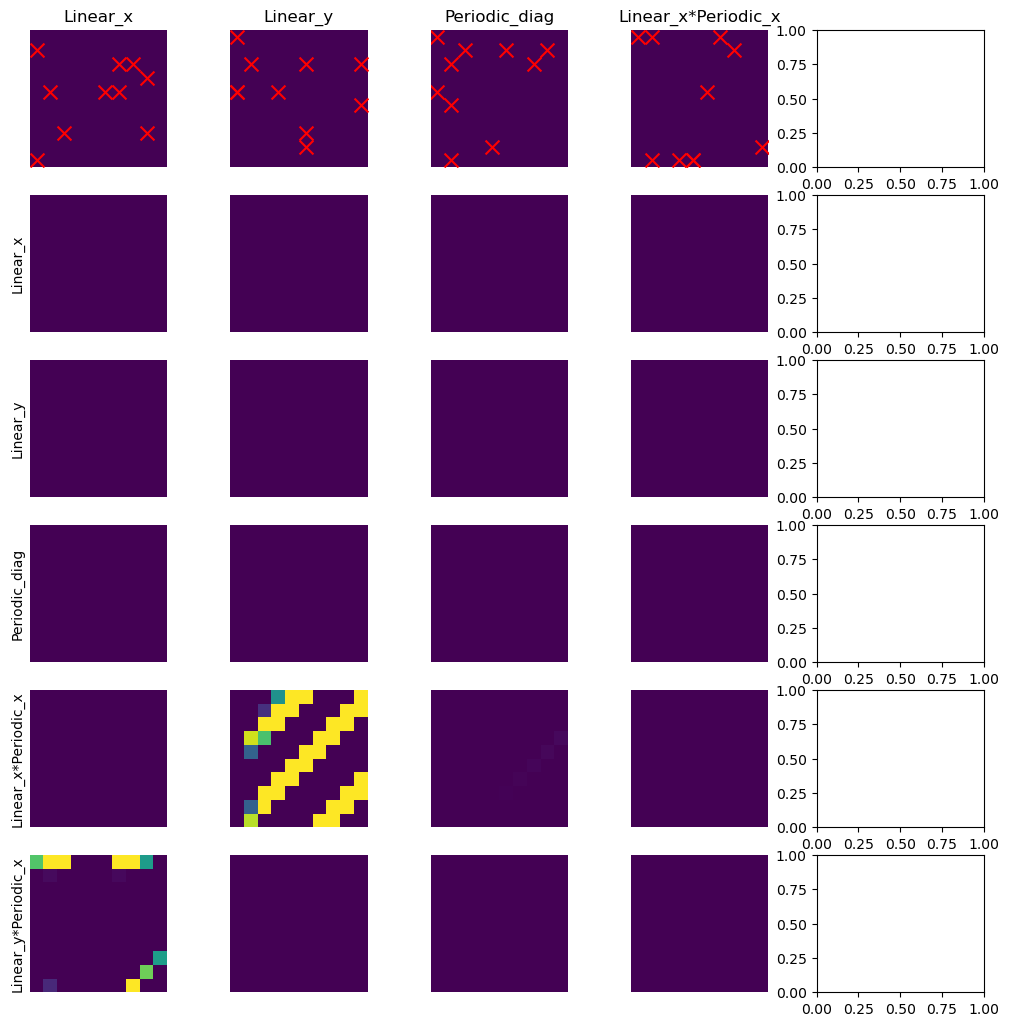

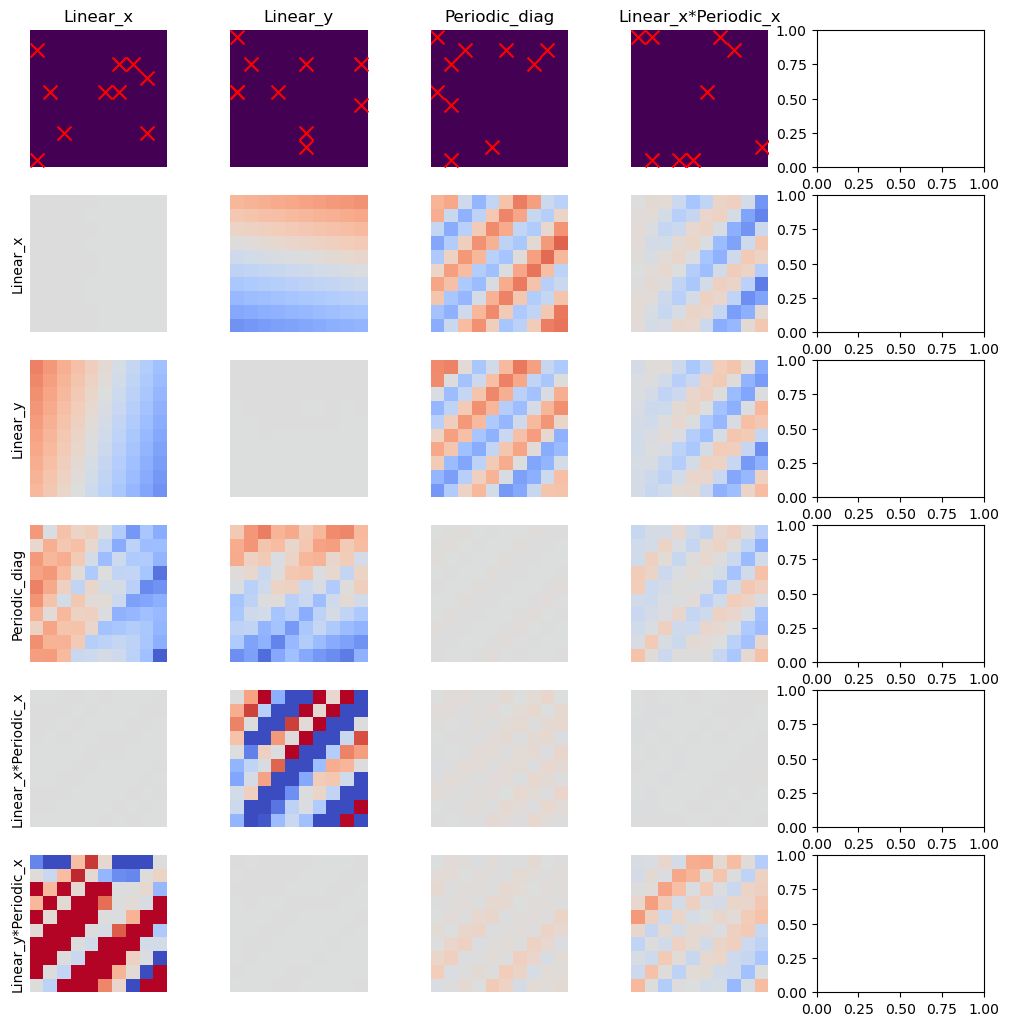

In [20]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

### zero in on interesting combos

## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
sigma_f = [1]
length_scale = [N/2.5]
# length_scale = np.linspace(1,10,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## init dict to store data
gp_dict = {
    'gen_kernel': [],
    'inf_kernel': [],
    'n_obs': [],
    'trial': [],
    'k_mll': [],
    'x_1': [],
    'x_2': [],
    'reward_1': [],
    'reward_2': [],
    'CP_1': [],
    'CP_2': [],
    'p(correct)': []
}
for param in param_names:
    gp_dict[param] = []

## loop through parameter initialisations
for pci in tqdm(range(len(param_combos))):
    params = param_combos[pci]

    ## define koi
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        # gp.K_rbf,
        # gp.K_rbf_x,
        # gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        gp.K_lin_x*gp.K_periodic_x,
        gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        # 'RBF',
        # 'RBF_x',
        # 'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]


    ## init plots 
    n_k = len(koi)
    n_trials = 500
    if (pci == len(param_combos)-1):
        fig, axs = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))
        fig2, axs2 = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))



    ## loop through combos
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        gp.k_check(k_gen)

        ## loop through trials
        for t in range(n_trials):
        
            ## sample from combo kernel
            samples = gp.sample(k_gen)

            ## generate observations
            n_obs = 10
            all_obs = gp.gen_obs(samples, n_obs)
            
            ## for each trial, select two random points to choose between
            preds = gp.gen_preds(samples).squeeze()


            ## plot
            if (t == n_trials-1) & (pci == len(param_combos)-1):
                plot_r(samples, axs[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_r(samples, axs2[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_obs(all_obs, axs[0,kg], text=False)
                plot_obs(all_obs, axs2[0,kg], text=False)
            
            ## loop through inference kernels
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## incrementally increase the number of observations
                for o in range(n_obs):
                    obs = all_obs[:o+1]

                    ## calculate posterior of the points to compare, given the observations made so far
                    post_mean, post_cov = gp.post_pred(k_inf, obs, preds[:,0].astype(int))
                    # temp = 0.1
                    # choice_prob = softmax(post_mean/temp)
                    # choice_prob = gp.sigmoid(diff, tau)
                    choice_prob = [scipy.stats.norm.cdf(post_mean[0]-post_mean[1], 0, np.sum(np.diag(post_cov)))]
                    choice_prob.append(1-choice_prob[0])


                    ## compute log marginal likelihood under this kernel
                    ll = gp.likelihood(k_inf, obs)

                    ## save data
                    gp_dict['gen_kernel'].append(k_gen_name)
                    gp_dict['inf_kernel'].append(k_inf_name)
                    gp_dict['trial'].append(t)
                    gp_dict['k_mll'].append(ll)
                    gp_dict['n_obs'].append(o+1)
                    ## should also save the info about the observations somewhere
                    gp_dict['x_1'].append(preds[0,0])
                    gp_dict['x_2'].append(preds[1,0])
                    gp_dict['reward_1'].append(preds[0,-1])
                    gp_dict['reward_2'].append(preds[1,-1])
                    gp_dict['CP_1'].append(choice_prob[0])
                    gp_dict['CP_2'].append(choice_prob[1])
                    gp_dict['p(correct)'].append(choice_prob[np.argmax(preds[:,-1])])

                    ## save params
                    for param in param_names:
                        gp_dict[param].append(params[param_names.index(param)])
                
                ## plot the full posterior distribution once all observations have been made
                full_post_mean, _ = gp.post_pred(k_inf, obs)
                if (t == n_trials-1) & (pci == len(param_combos)-1):
                    plot_r(full_post_mean.reshape(N,N), axs[ki+1,kg], cbar = kg==(len(koi)-1))
                    RPE = samples-full_post_mean.reshape(N,N)
                    plot_RPE(RPE, axs2[ki+1,kg], cbar = (kg==(len(koi)-1)))
            

        ## loop through rows and add y-axis to the leftmost column
        if (t == n_trials-1) & (pci == len(param_combos)-1):
            for i in range(n_k):
                axs[i+1,0].set_ylabel(kernel_names[i])
                axs2[i+1,0].set_ylabel(kernel_names[i])

## convert ll_dict to df
df_gp = pd.DataFrame(gp_dict)

## Plots

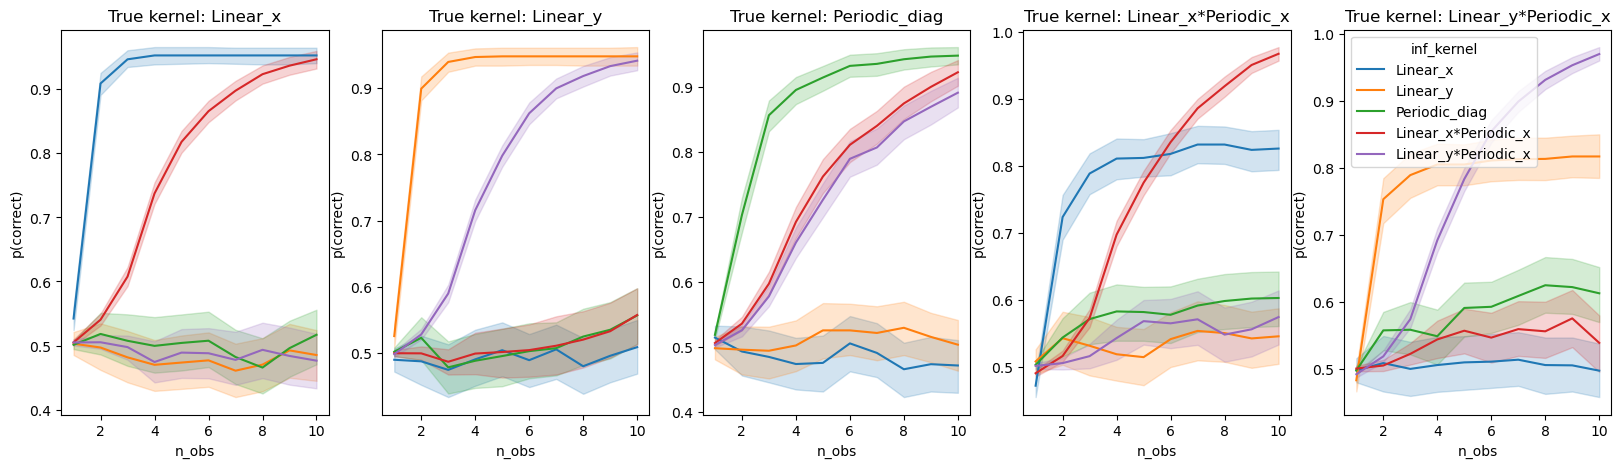

In [ ]:
## accuracy

# param_of_interest = scale.copy()
# param_of_interest = length_scale.copy()
# param_of_interest = period.copy()
param_of_interest = periodic_length_scale.copy()
for p in periodic_length_scale:
    data_tmp = df_gp.loc[df_gp['periodic_length_scale']==p]
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    for gki, gen_k in enumerate(data_tmp['gen_kernel'].unique()):
        sns.lineplot(data = data_tmp.loc[data_tmp['gen_kernel']==gen_k], x = 'n_obs', y = 'p(correct)', hue = 'inf_kernel', ax = axs[gki], legend = gki==n_k-1)
        axs[gki].set_title('True kernel: '+gen_k)
    # plt.suptitle((p))


## MLL

fig, axs = plt.subplots(1,n_k, figsize=(20,5))
for i in range(n_k):
    sns.lineplot(data = df_gp.loc[df_gp['gen_kernel'] == kernel_names[i]], x = 'n_obs', y = 'k_mll', hue = 'inf_kernel', ax = axs[i], legend=i==0, )
    axs[i].set_title('True kernel: '+kernel_names[i])
    axs[i].set_xlabel('N obs')
    axs[i].set_ylabel('')
    # axs[i].set_ylim(-100,25)
axs[0].set_ylabel('log marginal likelihood')
# axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Trajectories

## Optimal simulations

  0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/6f/wv4903p948xgctshsywsz13r0000gq/T/ipykernel_41590/397731463.py:207: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_gp = pd.concat([df_gp, df_tmp], ignore_index = True)


,simple_cost,simple_cost_x,simple_cost_y,optimal_cost,optimality,optimality_x,optimality_y
count,80.000000,40.000000,40.000000,80.000000,80.000000,40.000000,40.000000
mean,4.685082,6.481416,6.337259,3.674486,0.803205,0.647561,0.671667
std,1.712641,1.841917,2.163550,1.430919,0.185660,0.218170,0.207704
min,1.410759,2.954124,2.314403,1.040406,0.350390,0.245252,0.255073
25%,3.465542,5.479565,4.885688,2.731582,0.692489,0.480751,0.558341
50%,4.450775,6.422717,6.517586,3.514093,0.835635,0.630841,0.704756
75%,5.509889,7.254014,7.512765,4.433107,0.949448,0.844839,0.806828
max,10.534766,10.534766,12.179773,8.631548,1.000000,1.000000,1.000000


,gen_kernel,trial,n_simple,n_simple_x,n_simple_y,n_optimal,simple_cost,simple_cost_x,simple_cost_y,o_traj,...,optimality_y,metric,inf_under_RBF,RPE_under_RBF,inf_under_RBF_x,RPE_under_RBF_x,inf_under_RBF_y,RPE_under_RBF_y,inf_under_Periodic,RPE_under_Periodic
0,RBF,0,12,12,12,12,5.199266,5.199266,5.966738,"[(4, 8), (4, 7), (5, 7), (5, 6), (6, 6), (7, 6...",...,0.569715,manhattan,3.399343,0.0,5.390263,-1.99092,7.205095,-3.805752,5.88251,-2.483168
1,RBF,0,8,NaN,NaN,8,2.915875,NaN,NaN,"[(4, 8), (4, 7), (5, 6), (6, 5), (7, 4), (7, 3...",...,NaN,chebyshev,2.468464,0.0,2.67497,-0.206507,2.839318,-0.370854,3.966203,-1.497739
2,RBF_x,0,12,12,12,12,4.769891,7.101851,4.769891,"[(4, 8), (4, 7), (4, 6), (4, 5), (4, 4), (4, 3...",...,0.773182,manhattan,6.707538,-3.019546,3.687993,0.0,5.89383,-2.205837,7.000129,-3.312137
3,RBF_x,0,8,NaN,NaN,8,3.687993,NaN,NaN,"[(4, 8), (4, 7), (5, 6), (6, 5), (7, 4), (8, 3...",...,NaN,chebyshev,3.687993,-0.0,3.687993,0.0,3.687993,-0.0,5.150364,-1.462371
4,RBF_y,0,12,12,12,14,3.385943,9.900959,3.385943,"[(4, 8), (3, 8), (3, 7), (3, 6), (3, 5), (3, 4...",...,0.877228,manhattan,7.688394,-4.718151,5.247376,-2.277133,2.970243,0.0,10.917662,-7.947419
5,RBF_y,0,8,NaN,NaN,8,5.900959,NaN,NaN,"[(4, 8), (3, 7), (3, 6), (4, 5), (5, 4), (6, 3...",...,NaN,chebyshev,4.728363,-1.75812,4.970243,-2.0,2.970243,0.0,7.369156,-4.398913
6,Periodic,0,12,12,12,14,3.557214,3.557214,6.642353,"[(4, 8), (5, 8), (6, 8), (6, 7), (6, 6), (7, 6...",...,0.260556,manhattan,5.576435,-3.845731,7.040967,-5.310263,6.191897,-4.461193,1.730704,0.0
7,Periodic,0,8,NaN,NaN,10,1.828958,NaN,NaN,"[(4, 8), (5, 9), (6, 8), (6, 7), (7, 6), (7, 5...",...,NaN,chebyshev,4.509974,-3.243394,3.482572,-2.215992,6.10925,-4.84267,1.26658,0.0
8,RBF,1,11,11,11,11,6.055173,6.055173,7.206490,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",...,0.775824,manhattan,5.590971,0.0,8.163702,-2.572731,5.590971,0.0,6.575277,-0.984306
9,RBF,1,8,NaN,NaN,8,4.313135,NaN,NaN,"[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6...",...,NaN,chebyshev,3.735099,0.0,3.735099,0.0,4.421091,-0.685992,4.396914,-0.661816


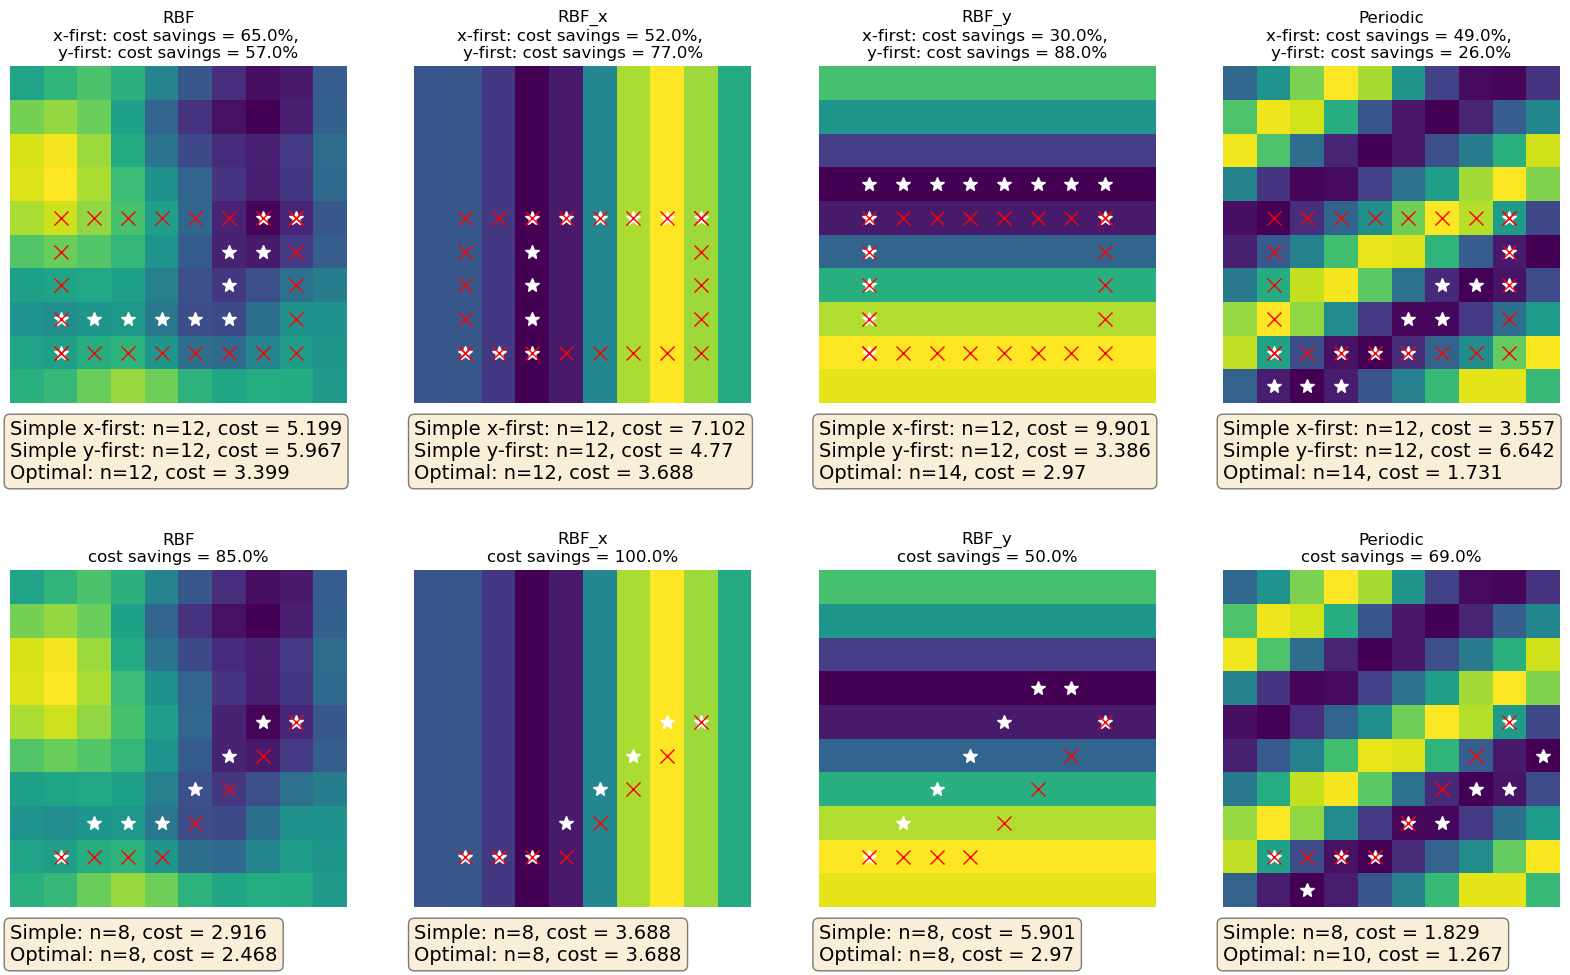

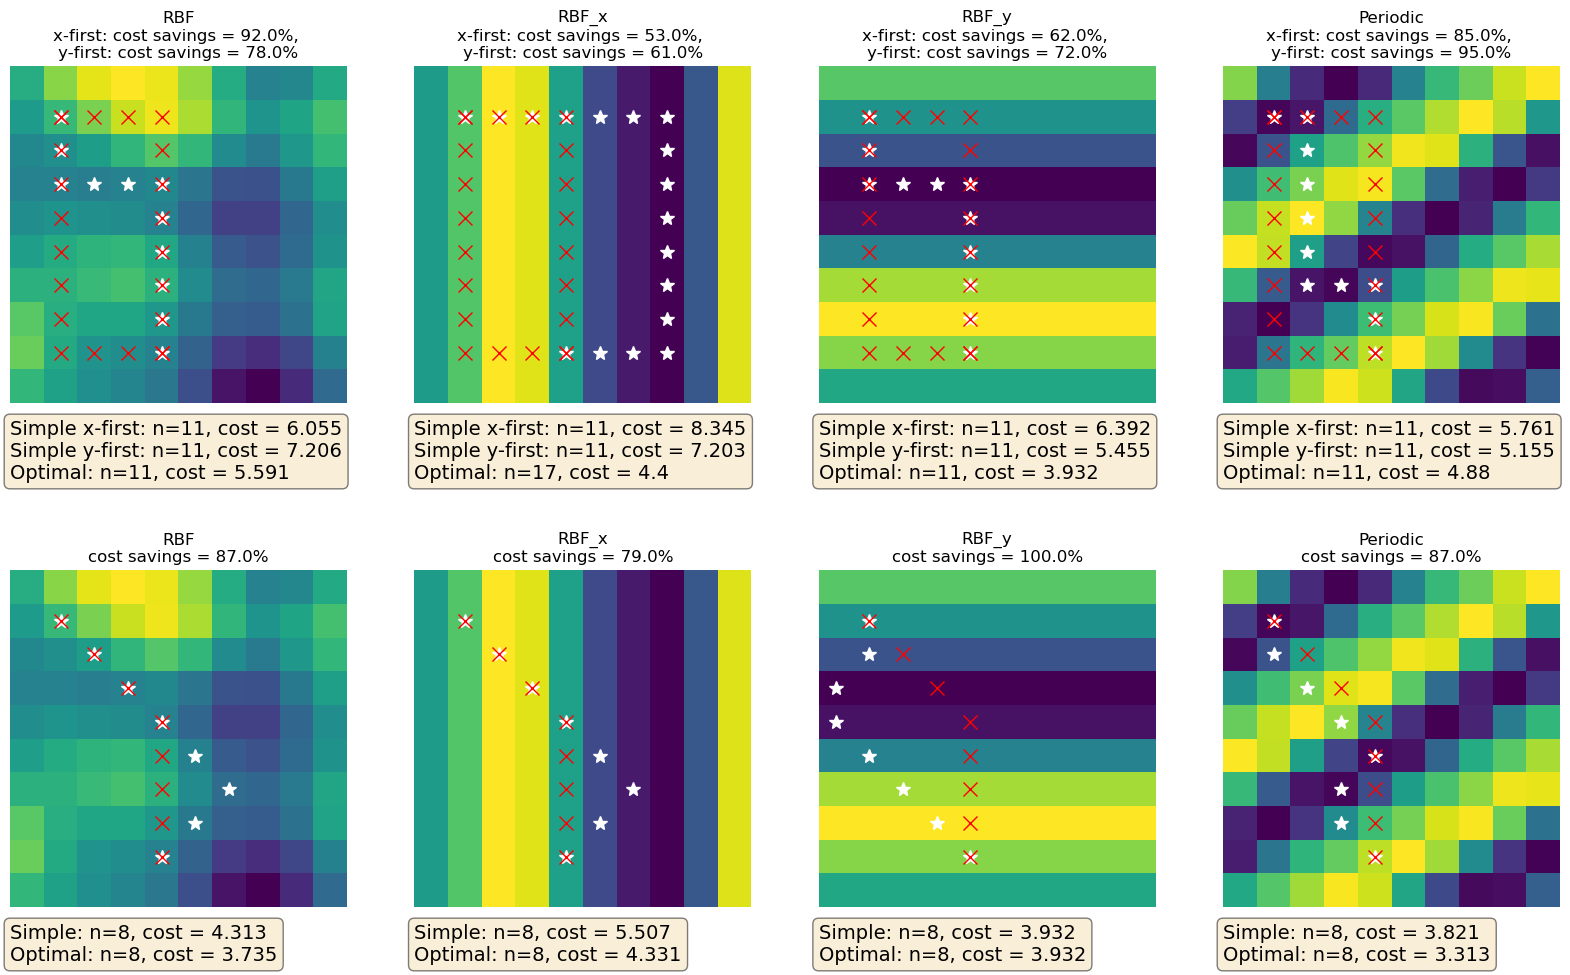

In [ ]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

# ## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
# theta = [np.pi/3]
sigma_f = [1]
length_scale = [N/5]
# length_scale = np.linspace(1,5,5, dtype = int)
period = [N/5]
# period = np.linspace(1,10,10)
# periodic_length_scale = [4]
periodic_length_scale = [N/2]
# periodic_length_scale = np.linspace(1,10,10)
periodic_theta = [0]
periodic_theta = [np.pi/3]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## loop through parameter initialisations
for pci in range(len(param_combos)):
    params = param_combos[pci]

    ## GP init
    metric = 'chebyshev'
    metric = 'manhattan'
    metrics = [
        'manhattan',
        'chebyshev'
        ]
    n_metrics = len(metrics)
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        # gp.K_lin_x,
        # gp.K_lin_y,
        gp.K_rbf,
        gp.K_rbf_x,
        gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        # gp.K_lin_x*gp.K_periodic_x,
        # gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        # 'Linear_x',
        # 'Linear_y',
        'RBF',
        'RBF_x',
        'RBF_y',
        'Periodic',
        # 'Periodic_y',
        # 'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        # 'Linear_x*Periodic_x',
        # 'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]
    
    ## init df to store data
    columns = [
        'gen_kernel',
        'trial',
        'x_1',
        'x_2',
        'reward_1',
        'reward_2',
        'n_simple',
        'n_simple_x',
        'n_simple_y',
        'n_optimal',
        'simple_cost',
        'simple_cost_x',
        'simple_cost_y',
        'o_traj',
        'optimal_cost',
        'optimality',
        'optimality_x',
        'optimality_y',
        'metric'
    ]
    n_trials = 10
    all_samples = {}
    all_pairs = np.zeros((n_trials,2,2))
    for k_name in kernel_names:
        columns.append('inf_under_'+k_name)
        columns.append('RPE_under_'+k_name)
        all_samples[k_name] = np.zeros((n_trials,N,N))
    columns.extend(param_names)
    df_gp = pd.DataFrame(columns = columns)
    n_k = len(koi)
    plotting_ts = [0, 1,]

    ## loop through trials
    for t in tqdm(range(n_trials)):
        if t in plotting_ts:
            fig, axs = plt.subplots(n_metrics,n_k, figsize=(n_k*5,n_metrics*6))
            if n_metrics == 1:
                axs = np.expand_dims(axs, axis = 0)

        ## select start and end points (make sure they are far enough apart)
        min_dist = N*0.75
        dist = 0
        while dist<min_dist:
            pair = np.random.randint(1,N-1,(2,2))
            dist = np.max(cdist(pair, pair))
        all_pairs[t] = pair

        ## loop through kernels
        all_paths = []
        samples_tmp = {}
        for kg, k_gen in enumerate(koi):
            k_gen_name = kernel_names[kg]
            gp.k_check(k_gen)

            ## sample from kernel
            samples = gp.sample(k_gen)

            ## save sample for later simulations
            samples_tmp[k_gen_name] = samples
            all_samples[k_gen_name][t] = samples

            ## calculate simplest and optimal trajectories under each metric
            for mi, metric in enumerate(metrics):
                h_w = 0
                o_traj, o_route_cost = gp.optimal_trajectory(pair, samples, metric, h_w)
                n_optimal = len(o_traj)
                optimal_cost = np.sum(o_route_cost)

                ## append new row to df
                if metric == 'chebyshev':
                    traj, route_cost  = gp.trajectory(pair,samples,metric)
                    n_simple = len(traj)
                    simple_cost = np.sum(route_cost)
                    optimality = np.sum(o_route_cost)/np.sum(route_cost)
                    traj_x = np.nan
                    traj_y = np.nan
                    n_simple_x = np.nan
                    n_simple_y = np.nan
                    simple_cost_x = np.nan
                    simple_cost_y = np.nan
                    optimality_x = np.nan
                    optimality_y = np.nan
                elif metric == 'manhattan':
                    traj_x, route_cost_x  = gp.trajectory(pair,samples,metric,'x')
                    traj_y, route_cost_y  = gp.trajectory(pair,samples,metric,'y')
                    n_simple_x = len(traj_x)
                    n_simple_y = len(traj_y)
                    simple_cost_x = np.sum(route_cost_x)
                    simple_cost_y = np.sum(route_cost_y)
                    optimality_x = optimal_cost/simple_cost_x
                    optimality_y = optimal_cost/simple_cost_y

                    ## 'simple' is the better of the two simple trajectories (x-first or y-first)
                    traj = traj_x if simple_cost_x < simple_cost_y else traj_y
                    route_cost = route_cost_x if simple_cost_x < simple_cost_y else route_cost_y
                    simple_cost = np.sum(route_cost)
                    n_simple = len(traj)
                    optimality = optimal_cost/simple_cost
                row = pd.Series({
                    'gen_kernel': k_gen_name,
                    'trial': t,
                    'metric': metric,
                    'n_optimal': n_optimal,
                    'o_traj': o_traj,
                    'optimal_cost': optimal_cost,
                    'n_simple': n_simple,
                    'simple_cost': simple_cost,
                    'optimality': optimality,
                    'n_simple_x': n_simple_x,
                    'n_simple_y': n_simple_y,
                    'simple_cost_x': simple_cost_x,
                    'simple_cost_y': simple_cost_y,
                    'optimality_x': optimality_x,
                    'optimality_y': optimality_y,
                })
                df_tmp = pd.DataFrame(columns = columns)
                for key in row.keys():
                    df_tmp[key] = [row[key]]
                df_gp = pd.concat([df_gp, df_tmp], ignore_index = True)
                
                ## plot
                if t in plotting_ts:
                    if metric == 'chebyshev':
                        title = k_gen_name+'\ncost savings = '+str(np.round(100*optimality))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)#kg==(len(koi)-1))
                        plot_traj([o_traj, traj], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple: n={n_simple}, cost = {np.round(simple_cost, 3)}',
                            f'Optimal: n={n_optimal}, cost = {np.round(optimal_cost, 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)
                        
                    elif metric == 'manhattan':
                        title = k_gen_name+'\nx-first: cost savings = '+str(np.round(100*optimality_x))+'%'+', \ny-first: cost savings = '+str(np.round(100*optimality_y))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)
                        plot_traj([o_traj, traj_x, traj_y], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple x-first: n={n_simple_x}, cost = {np.round(simple_cost_x, 3)}',
                            f'Simple y-first: n={n_simple_y}, cost = {np.round(simple_cost_y, 3)}',
                            f'Optimal: n={n_optimal}, cost = {np.round(optimal_cost, 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)
                        
        ## for each sample distribution (i.e. generative kernel), calculate the cost of taking the optimal trajectory under each of the other (inference) kernels
        for kg, k_gen_name in enumerate(kernel_names):
            for ki, k_inf_name in enumerate(kernel_names):
                for mi, metric in enumerate(metrics):
                    # if kg != ki:
                    samples = samples_tmp[k_gen_name]
                    h_w = 0
                    inf_traj = df_gp.loc[(df_gp['gen_kernel']==k_inf_name) & (df_gp['metric']==metric) & (df_gp['trial']==t) & (df_gp['n_simple']>0)]['o_traj'].values[0]
                    inf_traj_cost = np.sum([samples[x, y] for x, y in inf_traj])
                    RPE = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t) & (df_gp['n_simple']>0)]['optimal_cost'].values[0] - inf_traj_cost
                    df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t), 'inf_under_'+k_inf_name] = inf_traj_cost
                    df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t), 'RPE_under_'+k_inf_name] = RPE

                        
        ## calculate entropy for the optimal paths on this trial                
        # entropy_tmp = gp.entropy(all_paths)
        # axs[mi,-1].text(0.0, -0.05, f'Entropy: {entropy_tmp}', transform=axs[mi,-1].transAxes, fontsize=14,
        #                             verticalalignment='top', bbox=props)
        # plt.suptitle('Entropy: '+str(entropy_tmp))

## delete columns where the sum of that column is nan
df_gp = df_gp.loc[:, df_gp.sum(min_count=1).notna()]
display(df_gp.describe())
display(df_gp.head(10))

## Similarity measures

<Axes: xlabel='gen_kernel', ylabel='RPE_under_RBF_y'>

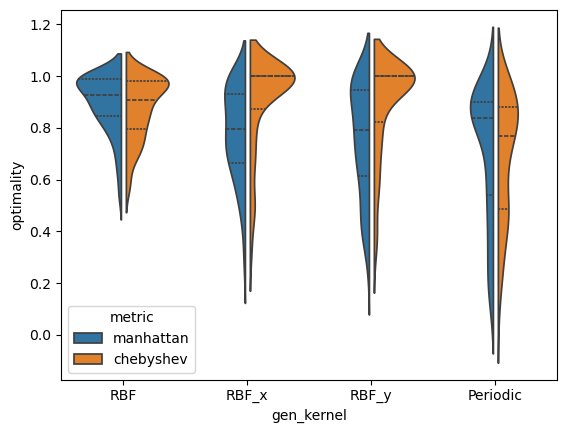

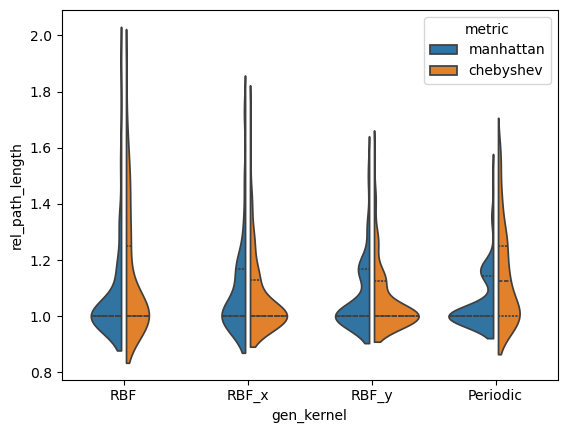

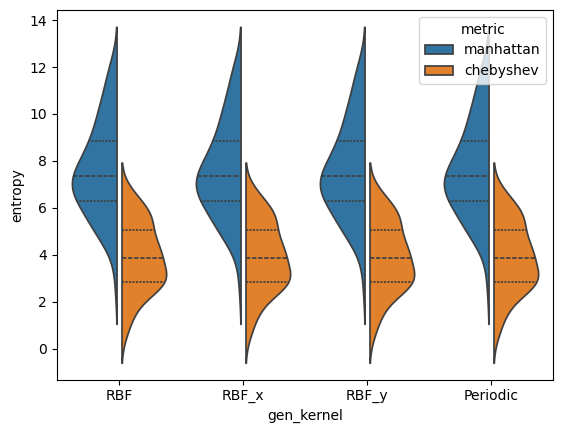

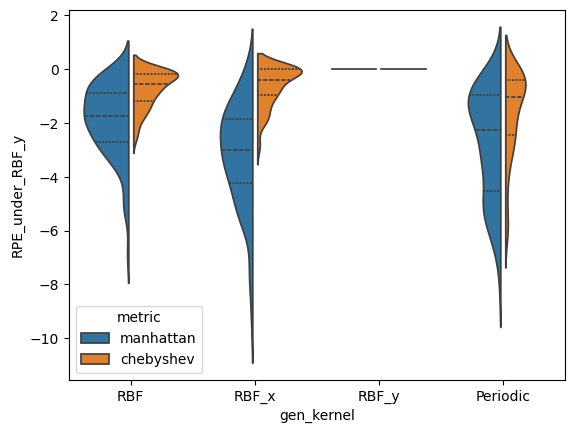

In [ ]:
## differences in structure-conferred optimal paths

## path lengths, relative to the simple path - i.e. how much longer is each kernel's optimal path compared to the simple path?
df_gp['rel_path_length'] = df_gp['n_optimal']/df_gp['n_simple']

## jaccard similarity between different optimal paths
for k in kernel_names:
    df_gp['vs '+k] = np.zeros(len(df_gp))
df_gp['mean jacc'] = np.zeros(len(df_gp))
df_gp['global_jacc'] = np.zeros(len(df_gp))
df_gp['entropy'] = np.zeros(len(df_gp))
df_gp['patch entropy'] = np.zeros(len(df_gp))

## loop through trials
for t in range(n_trials):
    jaccs = []

    ## loop through metrics
    for m in metrics:

        ## loop through kernels
        for k1 in kernel_names:
            path_1 = df_gp.loc[(df_gp['gen_kernel']==k1) & (df_gp['trial']==t) & (df_gp['metric']==m), 'o_traj'].values[0]

            ## calculate the jaccard similarity of paths with each other kernel-conferred path
            for k2 in kernel_names:
                if k1 == k2:
                    jaccs.append(np.nan)
                else:
                    path_2 = df_gp.loc[(df_gp['gen_kernel']==k2) & (df_gp['trial']==t)  & (df_gp['metric']==m), 'o_traj'].values[0]
                    jaccs.append(gp.jaccard(path_1, path_2))
                df_gp.loc[(df_gp['gen_kernel']==k1) & (df_gp['trial']==t)  & (df_gp['metric']==m), 'vs '+k2] = jaccs[-1]

        ## average
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'mean jacc'] = np.nanmean(jaccs)

        ## or, calculate the global jaccarrd similarity of all paths on that trial
        all_paths = df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'o_traj'].values
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'global_jacc'] = gp.global_jaccard(all_paths)

        ## equivalently, calculate the entropy-based diversity of the paths
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'entropy'] = gp.entropy(all_paths)
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'patch entropy'] = gp.patch_entropy(all_paths)


## plots
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'optimality', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'rel_path_length', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'entropy', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'RPE_under_RBF_y', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)

## Agent makes observations

In [ ]:
importlib.reload(plotter)
from plotter import *
"""
- Agent makes point observations from the true reward distribution
- After each observation, the agent calculates the posterior over the entire environment under each of the kernels, and then takes the optimal path under each of the kernels
- Alternatively, the observations are made along the route.
- The question is therefore whether we want exploration to be on-route, or route-independent
"""

## init info
n_obs = 8
columns = [
    'trial',
    'n_obs',
    'metric',
    'gen_kernel',
    'inf_kernel',
    'optimal_cost',
    'n_optimal',
    'actual_cost',
    'n_actual',
    'RPE'
]
df_agent = pd.DataFrame(columns = columns)
n_plotting_ts = 1
plotting_ts = np.random.randint(0,n_trials,n_plotting_ts)
# plotting_ts = [1]

plotting_metric = 'manhattan'

## for each trial
for t in tqdm(range(n_trials)):
# for t in tqdm(range(5)):
    pair = all_pairs[t]
    if t in plotting_ts:
        fig, axs = plt.subplots(n_k,n_obs+1, figsize=(n_obs*6,n_k*5))
        fig2, axs2 = plt.subplots(n_k,n_obs+1, figsize=(n_obs*6,n_k*5))

    ## for each generative kernel (i.e. true reward distribution)
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        true_samples = all_samples[k_gen_name][t]

        ## observations from true reward distribution
        all_obs = gp.gen_obs(true_samples, n_obs)

        ## plot true reward distribution and ground truth optimal path
        if t in plotting_ts:
            plot_r(true_samples, axs[kg,0], k_gen_name, cbar = kg==(len(koi)-1))
            optimal_traj = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==plotting_metric), 'o_traj'].values[0]
            plot_traj([optimal_traj], axs[kg,0])

            plot_r(true_samples, axs2[kg,0], k_gen_name, cbar = kg==(len(koi)-1))
            optimal_traj = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==plotting_metric), 'o_traj'].values[0]
            plot_traj([optimal_traj], axs2[kg,0])


        ## for each inference kernel
        for ki, k_inf in enumerate(koi):
            k_inf_name = kernel_names[ki]

            ## incrementally increase the number of observations
            for o in range(n_obs):
                obs = all_obs[:o+1]

                ## calculate posterior over the entire environment, given the observations made so far
                post_mean, post_cov = gp.post_pred(k_inf, obs)

                ## (UCB, i.e. give states with high posterior covariance, and therefore uncertain paths, extra weight?)
                # beta = 0.8
                # post_mean -= beta*np.sqrt(np.diag(post_cov)) #subtract, because the pathfinder is minimising cost

                if post_mean.min()<0: ## to ensure the posterior is non-negative
                    post_mean -= post_mean.min()

                ## agent takes route based on this posterior
                for metric in metrics:
                    actual_traj, _ = gp.optimal_trajectory(pair,post_mean.reshape(N,N),metric,0)
                    n_actual = len(o_traj)
                    actual_route_cost = [true_samples[x, y] for x, y in actual_traj]
                    actual_cost = np.sum(actual_route_cost)

                    ## calculate RPE
                    optimal_cost = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==metric), 'optimal_cost'].values[0]
                    # RPE = optimal_cost - actual_cost
                    RPE = actual_cost/optimal_cost 

                    row = pd.Series({
                        'trial': t,
                        'n_obs': o+1,
                        'metric': metric,
                        'gen_kernel': k_gen_name,
                        'inf_kernel': k_inf_name,
                        'optimal_cost': optimal_cost,
                        'n_optimal': n_optimal,
                        'actual_cost': actual_cost,
                        'n_actual': n_actual,
                        'RPE': RPE
                    })
                    df_tmp = pd.DataFrame(columns = columns)
                    for key in row.keys():
                        df_tmp[key] = [row[key]]
                    df_agent = pd.concat([df_agent, df_tmp], ignore_index = True)


                    ## after each observation, plot the posterior under the correct kernel, and its optimal path
                    if t in plotting_ts:
                        if metric == plotting_metric:
                            if k_inf_name == k_gen_name:
                                # title = k_gen_name#+'\n'+str(np.round(100*RPE/optimal_cost))+'%'
                                title = 'obs: '+str(o+1)
                                plot_r(post_mean.reshape(N,N), axs[kg,o+1], title, cbar = False)
                                plot_obs(obs, axs[kg,o+1], text=False)
                                plot_traj([optimal_traj,actual_traj], axs[kg,o+1])



        ### or, the agent makes observations and uses the marginal likelihoods of the inference kernels to make a weighted decision about which kernel to use

        ## incrementally increase the number of observations
        for o in range(n_obs):
            obs = all_obs[:o+1]
            lls = []
            post_means = []

            ## for each inference kernel
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## posterior over the entire environment, given the observations made so far
                post_mean, post_cov = gp.post_pred(k_inf, obs)
                # if post_mean.min()<0:
                #     post_mean -= post_mean
                post_means.append(post_mean)
            
                ## calculate the likelihood of the observations under this kernel
                ll = gp.likelihood(k_inf, obs)
                lls.append(ll)

            ## free params per kernel type? 
            # n_params = np.array([2, 3, 3, 4])
            # prior = penalised_uniform(n_params)
            # lls = lls*prior
            
            ## weight each posterior mean by the corresponding kernel's marginal likelihood
            k_weights = softmax(lls)
            weighted_post_mean = np.sum([k_weights[i]*post_means[i] for i in range(len(koi))], axis = 0)
            if weighted_post_mean.min()<0:
                weighted_post_mean -= weighted_post_mean.min()

            ## agent takes route based on this weighted posterior
            for metric in metrics:
                actual_traj, _ = gp.optimal_trajectory(pair,weighted_post_mean.reshape(N,N),metric,0)
                n_actual = len(o_traj)
                actual_route_cost = [true_samples[x, y] for x, y in actual_traj]
                actual_cost = np.sum(actual_route_cost)

                ## calculate RPE
                optimal_cost = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==metric), 'optimal_cost'].values[0]
                # RPE = optimal_cost - actual_cost
                RPE = actual_cost/optimal_cost 

                row = pd.Series({
                    'trial': t,
                    'n_obs': o+1,
                    'metric': metric,
                    'gen_kernel': k_gen_name,
                    'inf_kernel': 'weighted',
                    'optimal_cost': optimal_cost,
                    'n_optimal': n_optimal,
                    'actual_cost': actual_cost,
                    'n_actual': n_actual,
                    'RPE': RPE
                })
                ## save weight for each kernel
                for ki, k_inf in enumerate(koi):
                    k_inf_name = kernel_names[ki]
                    row['weight_'+k_inf_name] = k_weights[ki]
                df_tmp = pd.DataFrame(columns = columns)
                for key in row.keys():
                    df_tmp[key] = [row[key]]
                df_agent = pd.concat([df_agent, df_tmp], ignore_index = True)

                ## after each observation, plot the weighted posterior, and its optimal path
                if t in plotting_ts:
                    if metric == plotting_metric:
                        title = 'weighted kernel, obs: '+str(o+1)
                        plot_r(weighted_post_mean.reshape(N,N), axs2[kg,o+1], title, cbar = False)
                        plot_obs(obs, axs2[kg,o+1], text=False)
                        plot_traj([optimal_traj,actual_traj], axs2[kg,o+1])



        ## plot
        # if t in plotting_ts:
        #     for mi, metric in enumerate(['chebyshev']):
        #         title = k_gen_name
        #         plot_r(true_samples, axs[0,kg], title, cbar = kg==(len(koi)-1))
        #         plot_obs(all_obs, axs[0,kg], text=False)
        #         for ki, k_inf in enumerate(koi):
        #             k_inf_name = kernel_names[ki]
        #             post_mean, post_cov = gp.post_pred(k_inf, all_obs)
        #             title = k_inf_name
        #             plot_r(post_mean.reshape(N,N), axs[mi+1,kg], title, cbar = kg==(len(koi)-1))
        #             textstr = '\n'.join((
        #                 f'Optimal: n={n_optimal}, {np.round(optimal_cost, 3)}',
        #                 f'Actual: n={n_actual}, {np.round(actual_cost, 3)}',
        #                 f'RPE: {np.round(RPE, 3)}'))
        #             props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        #             axs[mi+1,kg].text(0.0, -0.05, textstr, transform=axs[mi+1,kg].transAxes, fontsize=14,
        #                         verticalalignment='top', bbox=props)






NameError: name 'plotter' is not defined

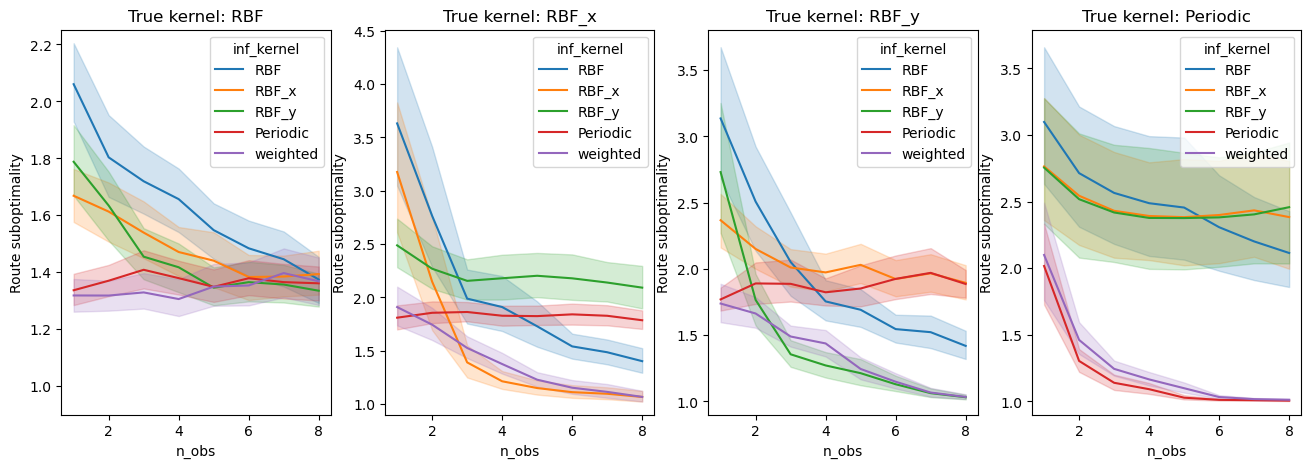

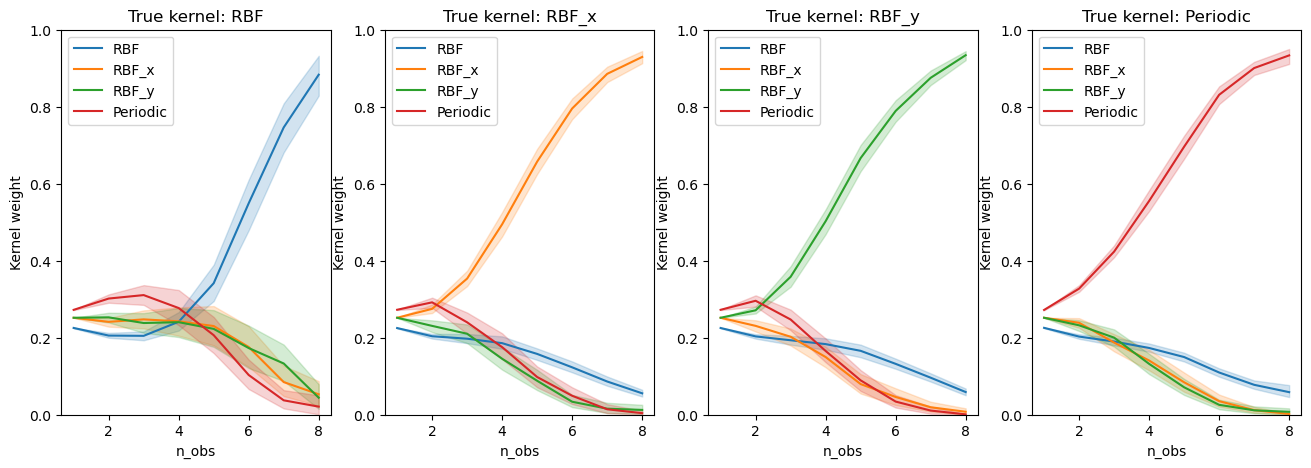

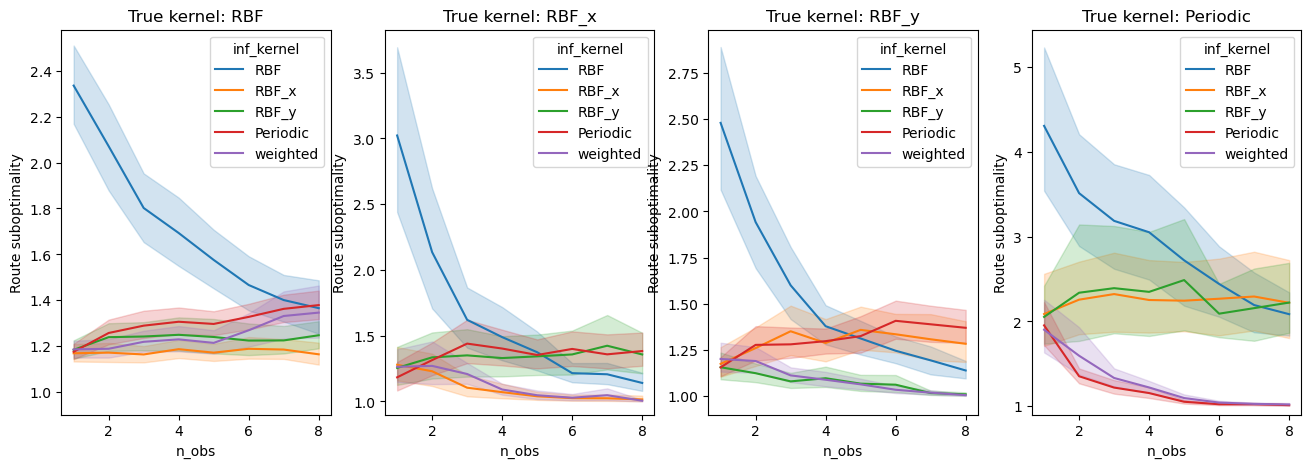

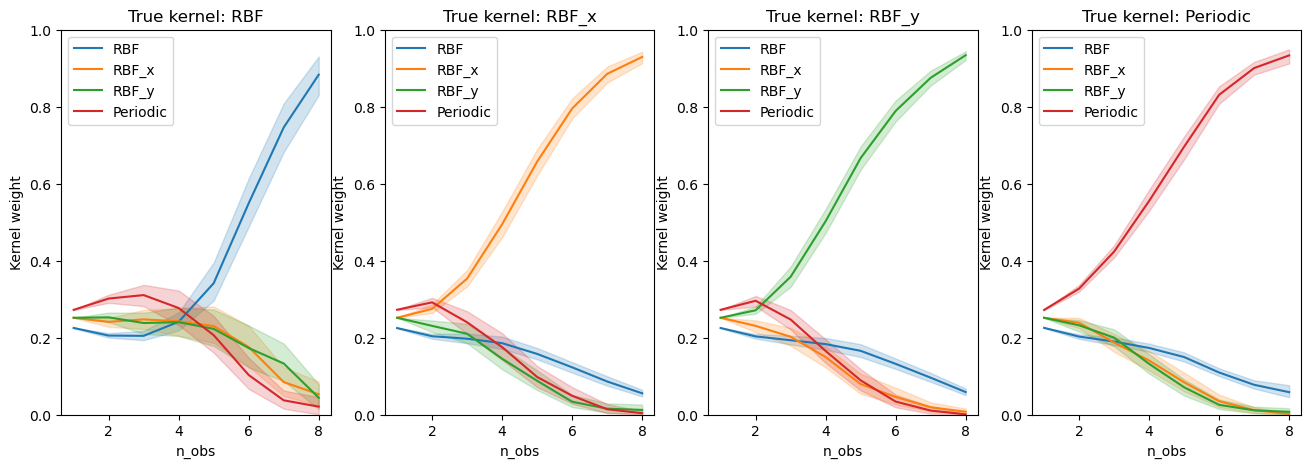

In [ ]:
for metric in metrics:
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    fig2, axs2 = plt.subplots(1, n_k, figsize=(4*n_k, 5))

    for gki, gen_k in enumerate(df_agent['gen_kernel'].unique()):
        data_tmp = df_agent.loc[(df_agent['gen_kernel']==gen_k) & (df_agent['metric']==metric)]
        sns.lineplot(data = data_tmp, x = 'n_obs', y = 'RPE', hue = 'inf_kernel', ax = axs[gki], markers = True)
        axs[gki].set_title('True kernel: '+gen_k)
        axs[gki].set_ylabel('Route suboptimality')
        axs[gki].set_ylim(0.9,)
        ## suptitle
        # plt.suptitle('Metric: '+metric)

        ## plot the weights of each inference kernel
        for iki, inf_k in enumerate(df_agent['gen_kernel'].unique()):
            sns.lineplot(data = data_tmp.loc[data_tmp['inf_kernel']=='weighted'], x = 'n_obs', y = 'weight_'+inf_k, ax = axs2[gki], markers = True, label = inf_k)
            axs2[gki].set_title('True kernel: '+gen_k)
            axs2[gki].set_ylabel('Kernel weight')
            axs2[gki].set_ylim(0,1)
        # sns.lineplot(data = data_tmp, x = 'n_obs', y = '', hue = 'inf_kernel', ax = axs2[gki], markers = True)

ValueError: not enough values to unpack (expected 4, got 2)

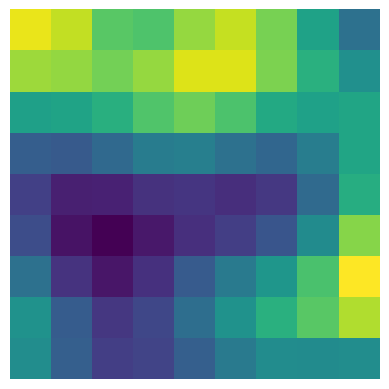

In [ ]:
## sample from a GP using an RBF kernel
gp = GP_world(9, params)
samples = gp.sample(gp.K_rbf)
axs = plt.subplot()
plot_r(samples,axs)

## imagine that P has made 3 observations from the left middle of the environment
axs = plt.subplot()
plot_r(samples,axs)
obs = np.array([[4,4],[4,5],[4,6]])
plot_obs(obs, axs)

# BAMCP 

## Single sim

In [ ]:
## GP inits
true_k = 'rbf_x'
true_k = 'rbf'
# true_k = 'periodic_y'
inf_k = 'weighted'
inf_k = 'known'
N = 10
metric = 'cityblock'
# metric = 'chebyshev'
r_noise = 0.025
random.seed(2)

true_ks = ['rbf', 'rbf_x', 'periodic_x']
n_ks = len(true_ks)

## trial info
n_mountains = 50
n_episodes = 10
scores = np.zeros((n_ks, n_mountains,n_episodes))

## loop through mountain types
for ki, true_k in enumerate(true_ks):
    print('True kernel: ', true_k)

    ## loop through mountains
    for m in tqdm(range(n_mountains)):

        ## çreate mountain environment
        env = make_env(N, None, metric, true_k, inf_k, render_mode=None, r_noise=r_noise)
        observation, info = env.reset()
        # env.render()
        # plot_r(env.costs, ax = plt.subplot(), title = 'True reward distribution')
        # plt.show()

        ## loop through episodes (i.e. different start and goal states for the same mountain)
        episode_scores =[]
        for e in range(n_episodes):
            end_episode = False
            terminated=False
            truncated=False

            ## run episode until goal is reached
            steps = 0
            total_cost = 0
            while not end_episode:

                ## init MCTS
                tree = Tree()
                MCTS = MonteCarloTreeSearch(env=env, tree=tree)
                n_sims = 1000
                
                ## tree search 
                for t in range(0, n_sims):
                    node = MCTS.tree_policy()
                    simulated_cost = MCTS.rollout_policy(node)
                    MCTS.backward(node, simulated_cost)

                ## get the simulated long-term costs of adjacent states
                current_children = MCTS.tree.children(MCTS.tree.root)
                MCTS_estimates = np.zeros(4)+ np.nan
                for child in current_children:
                    MCTS_estimates[child.action] = child.performance


                ## action selection
                action = np.nanargmax(MCTS_estimates)
                env.set_sim(False)
                observation, actual_cost, terminated, truncated, info = env.step(action)
                steps += 1
                total_cost += actual_cost
                # env.render()

                ## end the episode
                if terminated or truncated:
                    score = env.accrued_cost/env.optimal_cost
                    scores[ki, m, e] = score
                    # print('goal reached in ', steps, ' steps; total cost: ', total_cost, '; optimality: ', score)
                    observation, info = env.reset()
                    end_episode = True

        # MCTS.tree.show()
        # MCTS.forward()
    print('average score, ',true_k,': ',np.mean(scores[ki], axis = 0))

NameError: name 'random' is not defined

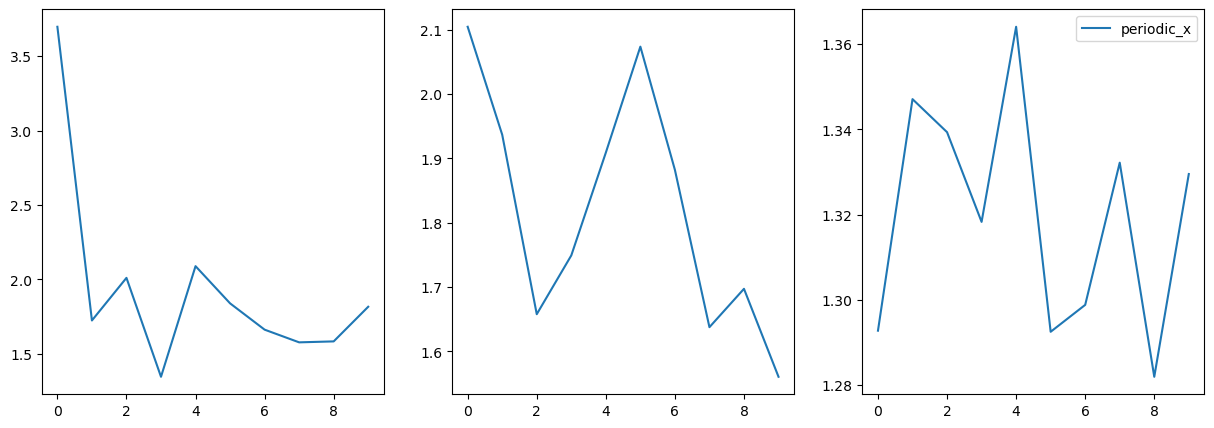

In [ ]:
## plot scores as lineplot
fig, axs = plt.subplots(1, n_ks, figsize=(5*n_ks, 5))
for ki, true_k in enumerate(true_ks):
    axs[ki].plot(np.arange(n_episodes), np.mean(scores[ki], axis = 0), label = true_k)
plt.legend()

## Parallel

In [422]:
### parallelising

## callback function for saving simulation results
def save_results(sim):
    sim_out = sim[0]
    # sim_out = sim


    ## save mountain surface
    all_mountains['mountain'].append(sim_out['mountain'][0])
    # all_mountains['true_k'].append(sim_out['true_k'][0])
    all_mountains['p_costs'].append(sim[1])

    ## save trial data
    # sim_results['agent'].extend(sim_out['agent'])
    # sim_results['mountain'].extend(sim_out['mountain'])
    # sim_results['episode'].extend(sim_out['episode'])
    # sim_results['start'].extend(sim_out['start'])
    # sim_results['goal'].extend(sim_out['goal'])
    # sim_results['true_k'].extend(sim_out['true_k'])
    # sim_results['actual_cost'].extend(sim_out['actual_cost'])
    # sim_results['optimal_cost'].extend(sim_out['optimal_cost'])
    # sim_results['action_score'].extend(sim_out['action_score'])
    # sim_results['cost_ratio'].extend(sim_out['cost_ratio'])
    # sim_results['n_steps'].extend(sim_out['n_steps'])
    # sim_results['RPE'].extend(sim_out['RPE'])
    # sim_results['search_attempts'].extend(sim_out['search_attempts'])
    # sim_results['theta_MLE'].extend(sim_out['theta_MLE'])
    for key in data_keys:
        sim_results[key].extend(sim_out[key])

    ## save trajectory info??
    # sim_results['actual_trajectory'].extend(sim_out['actual_trajectory'])
    # sim_results['optimal_trajectory'].extend(sim_out['optimal_trajectory'])
    # sim_results['observations'].extend(sim_out['observations'])
    # # sim_results['posterior_mean'].extend(sim_out['posterior_mean'])
    # sim_results['action_tree'].extend(sim_out['action_tree'])

    ## update progress bar
    master_pbar.update(1)

In [423]:
parallel=False

## init dictionary for saving simulation data
# sim_results = {
#     'agent': [],
#     'mountain': [],
#     'episode': [],
#     'start': [],
#     'goal': [],
#     'true_k': [],
#     'actual_cost': [],
#     'optimal_cost': [],
#     'action_score': [],
#     'cost_ratio': [],
#     'n_steps': [],
#     'actual_trajectory': [],
#     'optimal_trajectory': [],
#     'observations': [],
#     'RPE':[],
#     'search_attempts':[],
#     'posterior_mean':[],
#     'action_tree':[],
#     'theta_MLE':[],
# }
sim_results = {}
for key in data_keys:
    sim_results[key] = []


#### GP inits
true_k = 'rbf_x'
# true_k = 'rbf'
# true_k = 'periodic_y'
# inf_k = 'weighted'
inf_k = 'known'
N = 4
metric = 'cityblock'
# metric = 'chebyshev'
known_costs = False
obs_noise = 0.01
inf_noise = 0.01
params = None
render_mode = None

true_ks = [
    # 'rbf',
           'rbf_x',
        #    'periodic_x'
           ]
n_ks = len(true_ks)

## trial info
n_mountains = 1
n_episodes = 2

## MCTS params
n_trees = 100
n_futures = 0
exploration_constant = 2
discount_factor = 0.95
agents = [
    # 'GP',
        #    'GP-MCTS',
           'farmer'
          ]
# all_mountains = np.zeros((n_mountains, N,N))
all_mountains = {
    'mountain':[],
    'true_k':[],
    'p_costs':[]
}

## loop through mountain types
if __name__ == '__main__':
    for ki, true_k in enumerate(true_ks):
        master_pbar = tqdm(total=n_mountains, desc='All_{}_mountains'.format(true_k), position=0, leave=True, colour='green')

        ## begin parallelised simulations of mountains
        if parallel:

            ## start pool
            n_cores = np.min([10, n_mountains])
            with mp.Pool(n_cores) as pool:
                print('Parallel simulation of ', n_mountains, ' mountains, with ',n_episodes,' episodes, with kernel: ', true_k)
                sim_out = [pool.apply_async(simulate_agent, args=(m, N, params, metric, true_k, obs_noise, inf_noise, n_episodes, agents, n_trees, n_futures, exploration_constant, discount_factor),
                                             callback = save_results) for m in range(n_mountains)]
                pool.close()
                pool.join()

        else:

            ## loop through mountains
            for m in tqdm(range(n_mountains)):
                sim_out = simulate_agent(m, N, params, metric, true_k, obs_noise, inf_noise, n_episodes, agents, n_trees)
                save_results(sim_out)

print('Parallel complete')

## remove empty keys from dict
del_keys = []
for key in sim_results.keys():
    if not bool(sim_results[key]):
        del_keys.append(key)
for dk in del_keys:
    sim_results.pop(dk)

## dataframe of simulation results
df_sim = pd.DataFrame(sim_results)

All_rbf_x_mountains:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Mountain_0:   0%|          | 0/2 [00:00<?, ?it/s]

MCTS search:   0%|          

MCTS search:   0%|          

Parallel complete


In [ ]:
sim_out[0].get()

In [310]:
## remove empty keys from dict
del_keys = []
for key in sim_results.keys():
    if not bool(sim_results[key]):
        del_keys.append(key)
for dk in del_keys:
    sim_results.pop(dk)

## dataframe of simulation results
df_sim = pd.DataFrame(sim_results)


In [ ]:
## save df
df_sim.to_csv('env_{}_unknown_rewards_{}_mountains_{}_episodes_{}_trees_diff_corners.csv'.format(N, n_mountains, n_episodes, n_trees))

In [ ]:
pool.terminate()
pool.close()


In [424]:
## rm mountains with nan trials
nan_mountains = df_sim.loc[df_sim['action_score'].isna(), ['mountain']].to_numpy()
# print(df_sim.loc[df_sim['action_score'].isna(), ['actual_trajectory']].to_numpy())
# df_sim = df_sim.loc[~df_sim['mountain'].isin(nan_mountains.flatten())]
df_sim

,agent,mountain,episode,start,goal,actual_cost,optimal_cost,action_score,cost_ratio,n_steps,actual_trajectory,optimal_trajectory,observations,search_attempts,action_tree
0,farmer,0,0,"[3, 0]","[2, 3]",-3.7,-3.7,0.75,1.0,4,"[(3, 0), (2, 0), (2, 1), (2, 2), (2, 3)]","[(3, 0), (3, 1), (3, 2), (2, 2), (2, 3)]","[[3.0, 0.0, -0.1], [2.0, 0.0, -0.9], [2.0, 1.0...",1,None
1,farmer,0,1,"[3, 3]","[0, 1]",-3.0,-3.0,0.80,1.0,5,"[(3, 3), (2, 3), (2, 2), (1, 2), (0, 2), (0, 1)]","[(3, 3), (3, 2), (2, 2), (1, 2), (0, 2), (0, 1)]","[[3.0, 0.0, -0.1], [2.0, 0.0, -0.9], [2.0, 1.0...",1,None


AssertionError: Factor must have at least two levels.

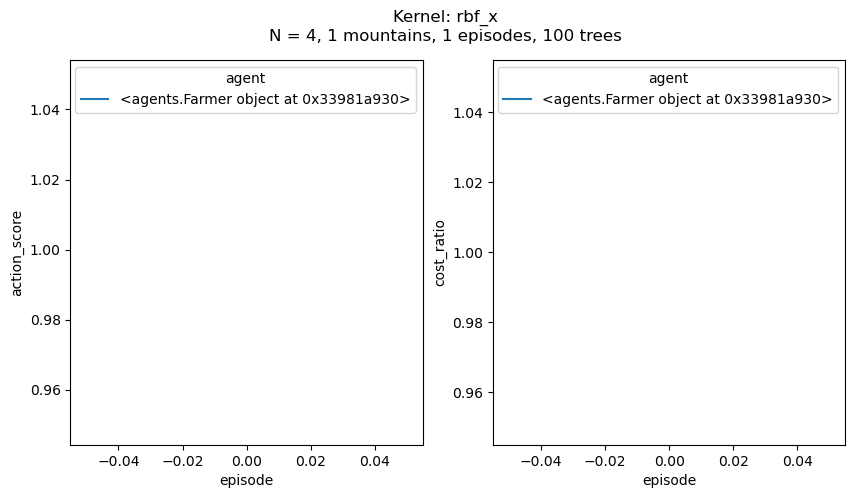

In [ ]:
## plots
fig, axs = plt.subplots(1,2, figsize = (10,5))
sns.lineplot(data = df_sim, x = 'episode', y = 'action_score', hue = 'agent',ax = axs[0])
sns.lineplot(data = df_sim, x = 'episode', y = 'cost_ratio', hue = 'agent', ax = axs[1])
plt.suptitle('Kernel: {}\nN = {}, {} mountains, {} episodes, {} trees'.format(true_k, N, n_mountains, n_episodes, n_trees))
# sns.lineplot(data = df_sim, x = 'episode', y = 'score', hue = 'true_k', style = 'agent', ax = axs[0])
# sns.lineplot(data = df_sim, x = 'episode', y = 'RPE', hue = 'true_k', style = 'agent', ax = axs[1])

## plot each mountain individually
# for m in range(n_mountains):
#     fig, axs = plt.subplots(1,2, figsize = (10,5))
#     sns.lineplot(data = df_sim.loc[df_sim['mountain']==m], x = 'episode', y = 'action_score', hue = 'agent', ax = axs[0])
#     sns.lineplot(data = df_sim.loc[df_sim['mountain']==m], x = 'episode', y = 'cost_ratio', hue = 'agent', ax = axs[1])

## 2x4 repeated measures ANOVA, with agent and episode as within-subjects factors
for score in ['action_score', 'cost_ratio']:
    anova = pg.rm_anova(data = df_sim, dv = score, within = ['agent', 'episode'], subject = 'mountain')
    print(score)
    display(anova)

In [ ]:
## box and whisker
sns.boxplot(data = df_sim, x = 'true_k', y = 'score', hue = 'agent',)
# sns.violinplot(data = df_sim, x = 'true_k', y = 'score', hue = 'agent', dodge=True)
sns.swarmplot(data = df_sim, x = 'true_k', y = 'score', hue = 'agent', dodge=True, marker = 'o', color = 'k',)
t1 = df_sim.loc[ (df_sim['agent']=='MCTS'), 'score']
t2 = df_sim.loc[ (df_sim['agent']=='GP'), 'score']
scipy.stats.ttest_rel(t1, t2)

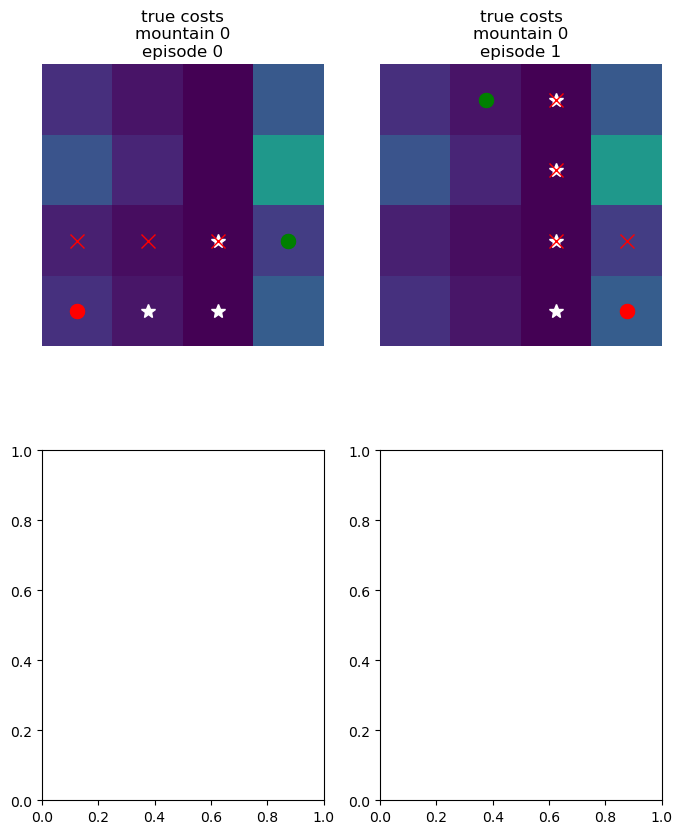

In [ ]:
## plot mountain surfaces with optimal paths
simulated_mountains = df_sim['mountain'].unique()
# simulated_mountains = [2]
# fig, axs = plt.subplots(len(simulated_mountains)*2, n_episodes, figsize = (10,10))
# if n_mountains == 1:
#     axs = np.expand_dims(axs, axis = 0)
for mi, m in enumerate(simulated_mountains):
    fig, axs = plt.subplots(2, n_episodes, figsize = (n_episodes*4,10))
    costs = all_mountains['p_costs'][mi] *-1
    plot_r(costs, ax = axs[0,0], title = 'true costs, mountain '+str(m))

    ## plot individual episodes
    for e in range(n_episodes):
        optimal_traj = df_sim.loc[(df_sim['mountain']==m) & (df_sim['episode']==e), 'optimal_trajectory'].values[0]
        actual_traj = df_sim.loc[(df_sim['mountain']==m) & (df_sim['episode']==e), 'actual_trajectory'].values[0]
        plot_r(costs, ax = axs[0,e], title = 'true costs\nmountain '+str(m)+'\nepisode '+str(e))
        plot_traj([optimal_traj, actual_traj], axs[0,e])

        ## plot posterior
        # post_mean = df_sim.loc[(df_sim['mountain']==m) & (df_sim['episode']==e), 'posterior_mean'].values[0].reshape(N,N)
        # plot_r(post_mean, ax = axs[0+1,e], title = 'posterior mean\nmountain '+str(m)+'\nepisode '+str(e))

        ## plot action tree



    # ## plot optimal path
    # optimal_traj = df_sim.loc[(df_sim['mountain']==m) & (df_sim['episode']==0), 'optimal_trajectory'].values[0]

## Debugging MCTS

start:  [0 4] goal:  [5 9]
[0.96 0.94 1.   0.98 0.93 0.81 0.98 0.97 0.99 0.98]
[0.55 0.95 0.23 0.72 0.99 0.99 0.97 0.38 0.67 0.85]


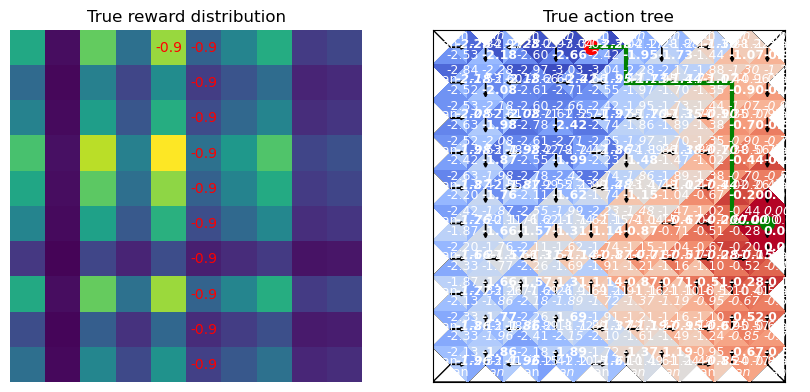

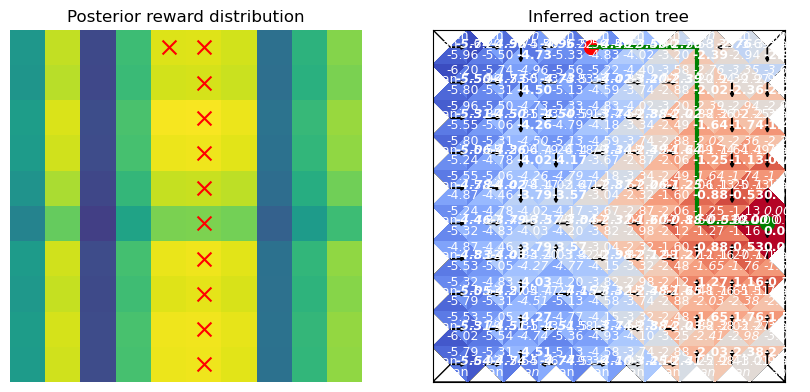

In [366]:
true_k = 'rbf_x'
N=10
env = make_env(N, true_k, None, 'cityblock', 0.01)

## give the agent some observations
n_obs = 10
obs = np.zeros((n_obs,3))
# obs[:,1] = np.random.randint(0,10,n_obs)
# obs[:,2] = np.random.randint(0,10,n_obs)
obs[:,0] = np.arange(n_obs)
obs[:,1] = np.zeros(n_obs)+N/2
# obs[:,3] = np.random.choice([-0.1,-0.9], n_obs)]
obs[:,2] = np.ones(n_obs) * -0.9
env.set_obs(obs)

env.reset()
print('start: ', env.current, 'goal: ', env.goal)
fig, axs = plt.subplots(1,2, figsize = (10,5))
plot_r(env.p_costs*-1, ax = axs[0], title = 'True reward distribution')
plot_obs(env.obs, ax = axs[0], text=True)
plot_action_tree(env.Q_true, env.current, env.goal, ax = axs[1], title='True action tree')


farmer = Farmer(N)
farmer.get_env_info(env)
farmer.root_sample(farmer.obs)
farmer.dp(expected_cost=True)
fig, axs = plt.subplots(1,2, figsize = (10,5))
plot_r(farmer.posterior_p_cost*-1, axs[0], title = 'Posterior reward distribution')
plot_obs(env.obs, ax = axs[0], text=False)
plot_action_tree(farmer.Q_inf, env.current, env.goal, ax = axs[1], title='Inferred action tree')

print(farmer.posterior_p.round(2))
print(farmer.posterior_q.round(2))

In [386]:
## set seed for reproducibility
# np.random.seed(3)

N=8
true_k = 'rbf'
true_k = 'rbf_x'
# true_k = 'periodic_x'
inf_k = 'known'
known_costs=False
obs_noise = 0.05
inf_noise = 0.05
print('initialising...')
kernel_params = None
env = make_env(N, true_k, kernel_params, 'cityblock', obs_noise)
print('env created')
env.reset()
print('episode initialised')

## copy env
env_copy = copy.deepcopy(env)
env_copy.set_sim(True)

## set start?
# start = [2,2]
# start = [0,0]
# env_copy.set_state(start)
start = env_copy.current
goal = env_copy.goal

## get info
info = env_copy.get_obs()
print('start: ', start, '; goal: ', goal, 'first obs: ', env_copy.costs[info['agent'][0], info['agent'][1]])

## init GP
# K_inf = None
# # K_inf = env.K_gen
# GP = GPAgent(N, K_inf, env.metric, inf_noise)
# GP.get_env_info(env)

## or init farmer
farmer = Farmer(N)
farmer.get_env_info(env)
# farmer.root_sample(farmer.obs)
# farmer.dp(expected_cost=True)


## one search
tree = Tree(N)
discount = 0.95
# expl = np.sqrt(2)
expl = 2
MCTS = MonteCarloTreeSearch(env=env_copy, agent = farmer,tree=tree, exploration_constant=expl, discount_factor=discount)
n_trees = 10
n_futures = 0
assert MCTS.env.sim == True
assert env_copy.sim==True
action = MCTS.search(n_trees, n_futures=n_futures, progress=True)
MCTS.tree.action_tree()

initialising...
env created
episode initialised
start:  [4 4] ; goal:  [0 0] first obs:  -0.9


MCTS search:   0%|          

0.00018105764454950243
0.4781127555823858
0.10882858989871924
0.19191724110207697
0.06473480669625589
0.030961338178672082
0.22694982322959456
0.3059019779526808
0.0007501261700037716
0.43128570564703245


<Axes: title={'center': 'DP_true'}>

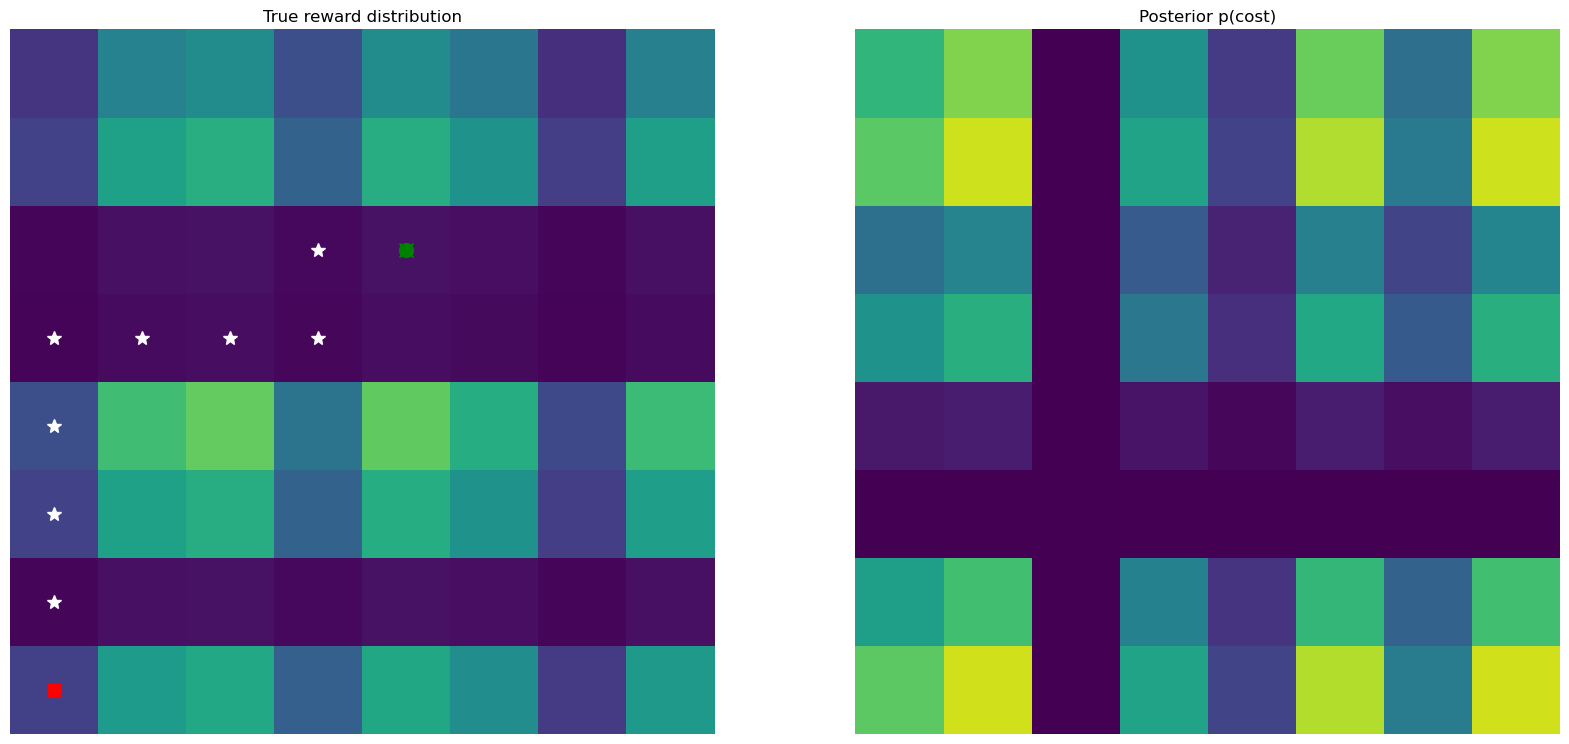

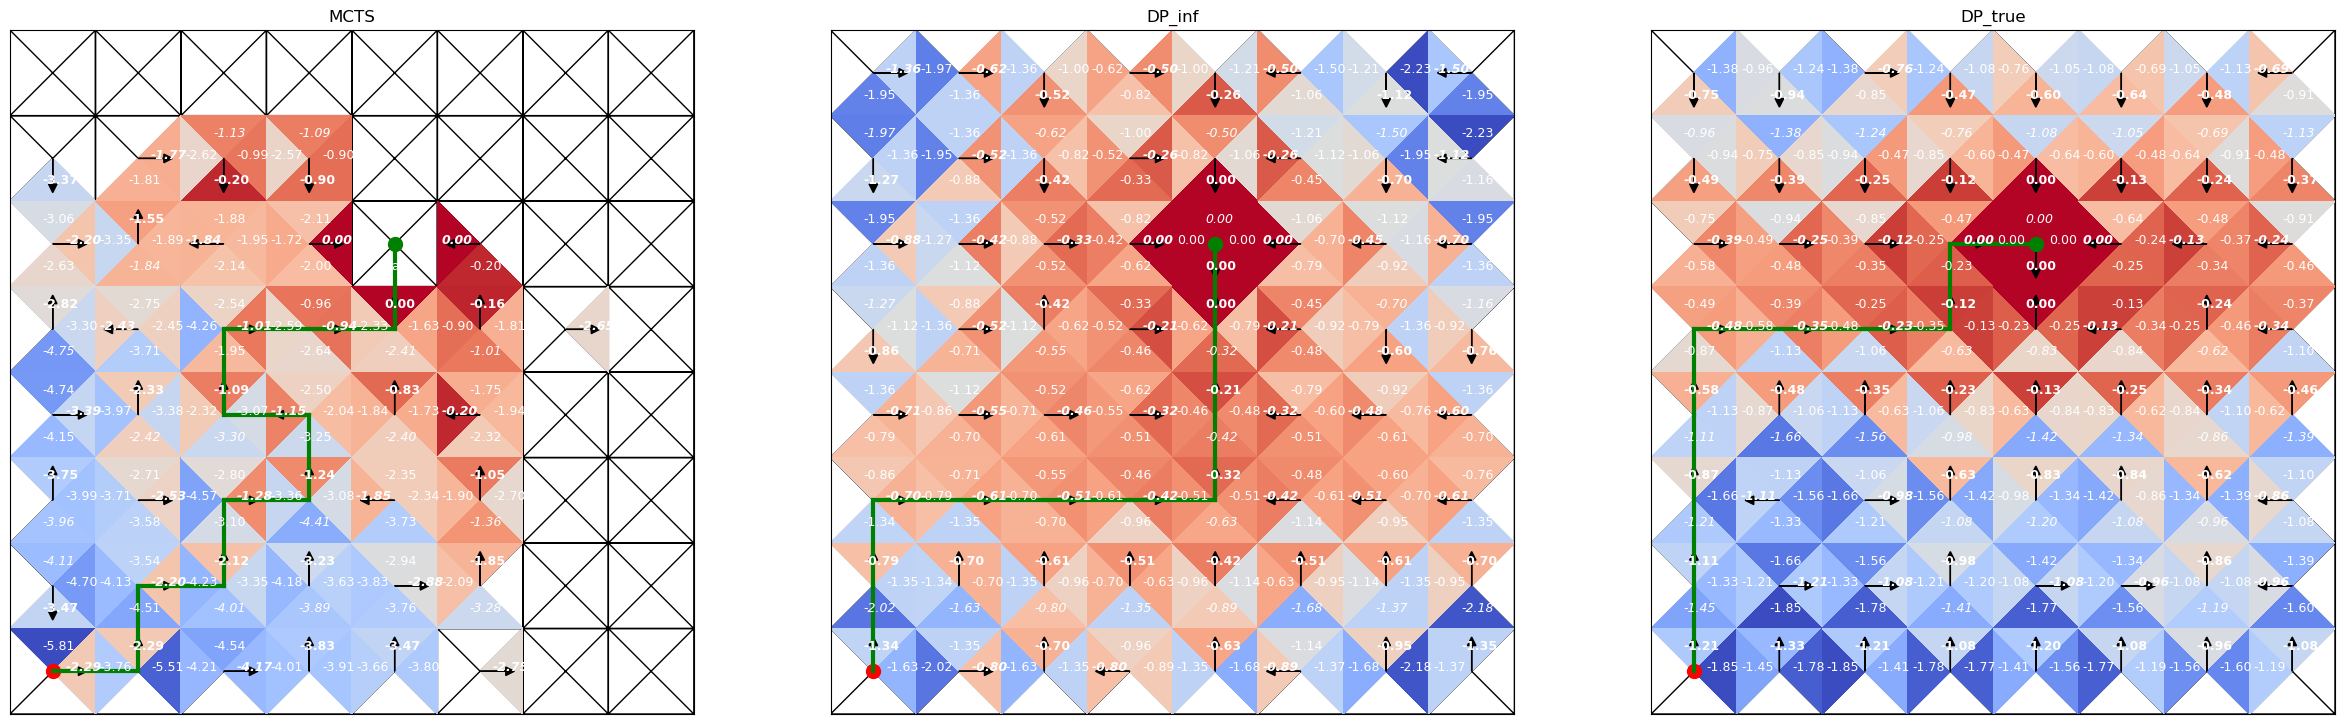

In [385]:
from utils import sample

## plot env
MCTS.tree.action_tree()
fig, axs = plt.subplots(1,2, figsize = (20,10))
costs = env_copy.p_costs.copy()*-1
# costs += env_copy.r_noise*np.random.randn(N,N)
plot_r(costs, ax = axs[0], title = 'True reward distribution', cbar=False)
axs[0].scatter(info['agent'][1]+0.5, info['agent'][0]+0.5, c = 'r', s = 100, marker = 'x')
axs[0].scatter(info['goal'][1]+0.5, info['goal'][0]+0.5, c = 'g', s = 100, marker = 'x')
plot_traj([env.o_traj], ax = axs[0])


### farmer plotting:

## plot posterior mean and post distr
pred = farmer.posterior_p_cost.reshape(N,N) *-1
# pred += np.sqrt(GP.posterior_var.reshape(N,N)) * env.expl_beta
plot_r(pred, ax = axs[1], title = 'Posterior p(cost)', cbar=False)

## plot MCTS tree along with DP Q values
fig, axs = plt.subplots(1,3, figsize = (30,10))
plot_action_tree(MCTS.tree.tree_q, info['agent'], info['goal'], ax = axs[0], title='MCTS' )
plot_action_tree(farmer.Q_inf, env.get_obs()['agent'], env.get_obs()['goal'], ax=axs[1], title = 'DP_inf')
plot_action_tree(env.Q_true, env.get_obs()['agent'], env.get_obs()['goal'], ax=axs[2], title = 'DP_true')



### GP plotting:

## plot posterior mean and post distr
# pred = GP.posterior_mean.reshape(N,N) 
# # pred += np.sqrt(GP.posterior_var.reshape(N,N)) * env.expl_beta
# plot_r(pred, ax = axs[1], title = 'Posterior mean', cbar=False)


# post_dist = sample(GP.posterior_mean, GP.posterior_cov, ).reshape(N,N)
# plot_r(post_dist, ax = axs[2], title = 'Posterior distr', cbar=False)

# ## plot MCTS tree along with DP Q values
# fig, axs = plt.subplots(1,3, figsize = (30,10))
# plot_action_tree(MCTS.tree.tree_q, info['agent'], info['goal'], ax = axs[0], title='MCTS' )
# plot_action_tree(GP.Q_inf, env.get_obs()['agent'], env.get_obs()['goal'], ax=axs[1], title = 'DP_inf')
# plot_action_tree(env.Q_true, env.get_obs()['agent'], env.get_obs()['goal'], ax=axs[2], title = 'DP_true')

# print(env_copy.obs)
# print(np.round(env_copy.posterior_mean,3))
# plt.figure()
# sns.histplot(env_copy.posterior_mean.flatten())
# plt.figure()
# sns.heatmap(env_copy.posterior_mean.reshape(N,N), annot=True)

In [391]:
print('post mean around obs:', env_copy.posterior_mean.reshape(N,N)[start[0], start[1]])

# post_sample = env_copy.sample_post(env_copy.posterior_mean, env_copy.posterior_cov)
post_sample = env_copy.sample(env_copy.posterior_cov, env_copy.posterior_mean)
# print(post_sample.min(), post_sample.max(), post_sample.mean())

fig, axs = plt.subplots(1,2, figsize = (15,7.5))
plot_r(post_sample, axs[0])
print('post sample around obs:', post_sample[start[0], start[1]])

## DP under this posterior
V,Q,A = env_copy.value_iteration(post_sample)
plot_action_tree(Q, env.get_obs()['agent'], env.get_obs()['goal'], ax=axs[1])


AttributeError: 'MountainEnv' object has no attribute 'posterior_mean'

## Farming

<Axes: title={'center': 'DP wrt expected costs'}>

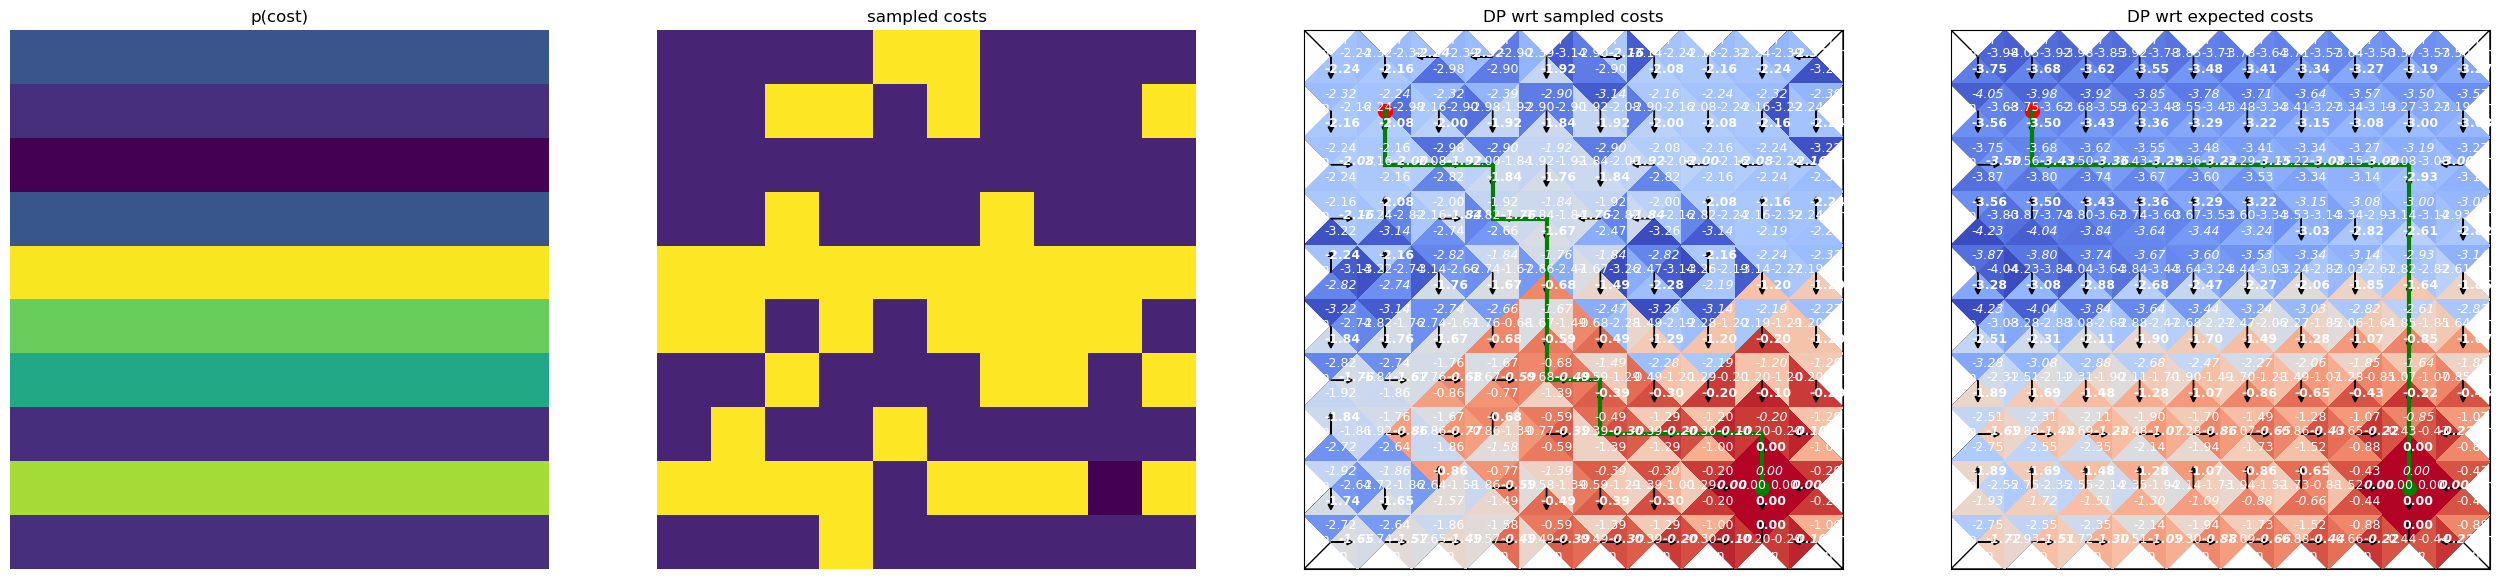

In [334]:
## product of probabilities
N=10
p = np.linspace(0,1,100)
q = p.copy()
z = np.zeros((100,100))
for pi in range(100):
    for qi in range(100):
        z[pi,qi] = p[pi]*q[qi]
# sns.heatmap(z)

## plot beta distributions for different alpha and beta params
from scipy.stats import beta
a = 0.5
b=0.5
x = np.linspace(0,1,100)
y = beta.pdf(x,a,b)

#plot
# plt.figure()
# plt.plot(x,y)

## sample from this beta distributino
row_p = np.random.beta(b,a,N)
column_q = np.random.beta(a,b,N)
column_q = np.ones(N)
# column_q = np.random.beta(2,1,N)
z = np.outer(row_p, column_q)*-1
fig, axs = plt.subplots(1,4, figsize = (32,8))
plot_r(z, axs[0], title='p(cost)')

## dp by filling in the costs
goal = [8,8]
random_numbers = np.random.rand(N,N)
dp_costs = np.array([-1 if r<-z.flatten()[ri] else -0.1 for ri, r in enumerate(np.random.rand(N**2))]).reshape(N,N)
dp_costs[goal[0], goal[1]] = 0
plot_r(dp_costs, axs[1], title='sampled costs')

# plot_r(dp_costs, axs[1])
V,Q,A = value_iteration(dp_costs, goal)
plot_action_tree(Q, [1,1], goal, ax = axs[2], title = 'DP wrt sampled costs')

## or, dp according to expected costs
dp_costs = z.copy()*-1
dp_costs = dp_costs*-1 + (1-dp_costs)*-0.1
V,Q,A = value_iteration(dp_costs, goal)
plot_action_tree(Q, [1,1], goal, ax = axs[3], title = 'DP wrt expected costs')

In [265]:
random_numbers

array([[0.38653828, 0.88581999, 0.37593266, 0.56214419, 0.73757666,
        0.05634631, 0.66907837, 0.59986117, 0.89904806, 0.72683476],
       [0.38970003, 0.32149866, 0.16495663, 0.33297167, 0.62314574,
        0.4576121 , 0.95651483, 0.14049229, 0.55720573, 0.8950642 ],
       [0.24434892, 0.58672725, 0.6837455 , 0.24370377, 0.12331895,
        0.15226113, 0.57713246, 0.41420783, 0.43714679, 0.27163474],
       [0.04710229, 0.42060746, 0.95168973, 0.68584506, 0.30683   ,
        0.6387091 , 0.68409529, 0.05099963, 0.52343704, 0.7869931 ],
       [0.26830958, 0.80246268, 0.65366808, 0.9101597 , 0.28472307,
        0.4942674 , 0.51232474, 0.03780428, 0.79214599, 0.78550492],
       [0.19215105, 0.48449586, 0.70921892, 0.91635173, 0.51438499,
        0.79190265, 0.23460522, 0.04685696, 0.00343122, 0.47041032],
       [0.30260377, 0.87942531, 0.14886062, 0.13221113, 0.13608667,
        0.7624304 , 0.0328197 , 0.38204014, 0.33417642, 0.69673721],
       [0.30962849, 0.28147481, 0.3047804